# 01 Feature Extraction

## Setup and imports

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
requirements_path = "/content/drive/MyDrive/xai-project5/requirements.txt" if IN_COLAB else "requirements_ai_core.txt"

!pip install -r "{requirements_path}"

In [8]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn
from transformers import AutoProcessor, AutoModel
from PIL import Image
from datasets import load_dataset
from tqdm import tqdm # Per la barra di avanzamento
import os

In [15]:
if IN_COLAB:
    save_dir = '/content/drive/MyDrive/xai-project5/results/feature_extraction'
else:
    save_dir = os.path.abspath(os.path.join('..', 'results', 'feature_extraction'))

os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'nih_chest_embeddings.pt')
print(f"Salvataggio configurato su: {save_path}")

Salvataggio configurato su: /content/drive/MyDrive/xai-project5/results/feature_extraction/nih_chest_embeddings.pt


## Model and Dataset

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_id = "flaviagiammarino/pubmed-clip-vit-base-patch32"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id).to(device)

model.eval() #è già pre-addestrato

print("Scaricamento del dataset di radiografie in corso...")
dataset = load_dataset("g-ronimo/NIH-Chest-X-ray-dataset_10k", split="train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:134: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

README.md:   0%|          | 0.00/830 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/457M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/153M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [ ]:
# Labels visualization
dataset['labels']

Column([[0], [0], [11], [4], [11, 13]])

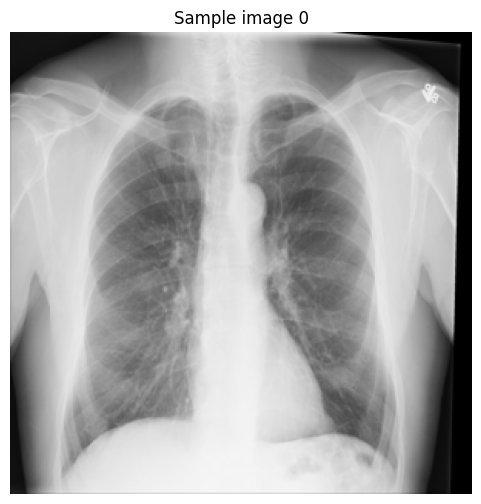

In [ ]:
# Visualization of a sample image
import matplotlib.pyplot as plt

sample_idx = 0
image = dataset[sample_idx]["image"]

if image.mode != "RGB":
    image = image.convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Sample image {sample_idx}")
plt.show()

## Extraction embedding and visualization

In [ ]:
checkpoint_path = os.path.join(save_dir, 'checkpoint_embeddings.pt')

if os.path.exists(checkpoint_path):
    print("Trovato checkpoint! Riprendo l'estrazione...")
    checkpoint = torch.load(checkpoint_path)
    all_embeddings = checkpoint['embeddings']
    start_idx = checkpoint['last_index'] + 1
else:
    all_embeddings = []
    start_idx = 0

print("Estrazione embedding visivi in corso....")

with torch.no_grad():
    for idx in tqdm(range(start_idx, len(dataset))):
        item = dataset[idx]
        image = item['image']

        if image.mode != "RGB":
            image=image.convert("RGB")

        inputs = processor(images=image, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        vision_outputs = model.get_image_features(**inputs)
        vision_tensor = vision_outputs.pooler_output
        vision_embeddings = F.normalize(vision_tensor, p=2, dim=1)
        all_embeddings.append(vision_embeddings.cpu())

        # Salviamo il checkpoint ogni 1000 immagini
        if (idx + 1) % 1000 == 0:
            torch.save({
                'embeddings': all_embeddings,
                'last_index': idx
            }, checkpoint_path)
            print(f"Checkpoint salvato al batch {idx + 1}")

dataset_tensor=torch.cat(all_embeddings,dim=0)
torch.save(dataset_tensor, save_path)

if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)

print(f"\nDataset salvato con successo. Shape: {dataset_tensor.shape}")

Estrazione embedding visivi in corso....


 13%|█▎        | 1000/7500 [05:03<40:54,  2.65it/s]

Checkpoint salvato al batch 1000


 27%|██▋       | 2000/7500 [09:22<29:08,  3.15it/s]

Checkpoint salvato al batch 2000


...

Checkpoint salvato al batch 6000


 93%|█████████▎| 7000/7500 [31:29<04:23,  1.90it/s]

Checkpoint salvato al batch 7000


100%|██████████| 7500/7500 [33:41<00:00,  3.71it/s]


Dataset salvato con successo. Shape: torch.Size([7500, 512])


Running t-SNE dimensionality reduction (512D -> 2D)...
Plotting results...


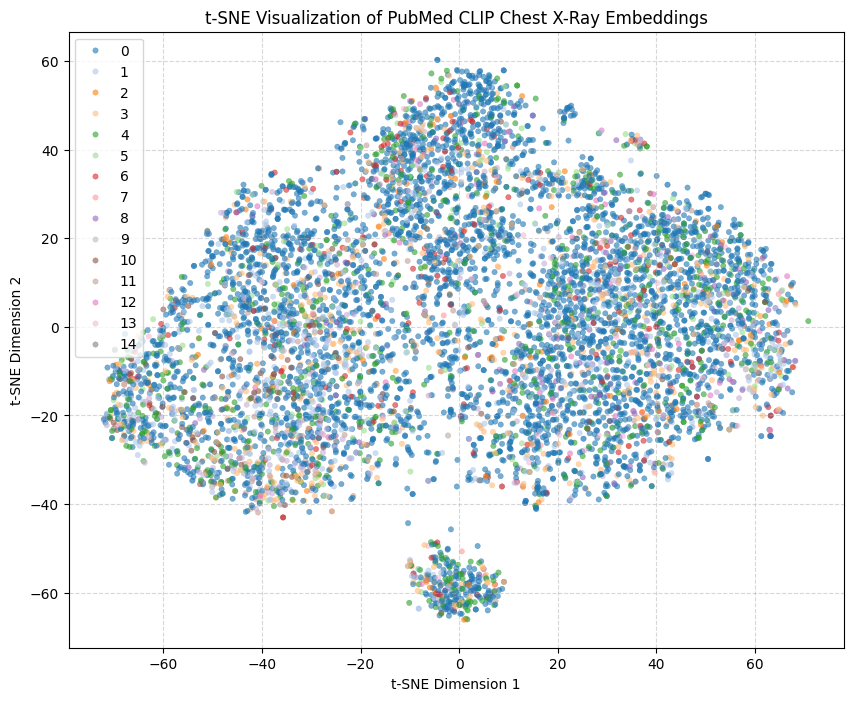

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Load the saved embeddings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embeddings_tensor = torch.load(save_path, map_location=device)

# Convert PyTorch tensor to a NumPy array
embeddings_np = embeddings_tensor.cpu().numpy()
# Note: t-SNE is computationally expensive, so we can slice the array and consider only a subset of the embeddings for visualization. 
#embeddings_np = embeddings_np[:2000] 

# Extract labels for coloring the scatter plot
primary_labels = [labels[0] if len(labels) > 0 else 0 for labels in dataset['labels']]

print("Running t-SNE dimensionality reduction (512D -> 2D)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_np)

print("Plotting results...")
# Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embeddings_2d[:, 0], 
    y=embeddings_2d[:, 1],
    hue=primary_labels,     
    palette="tab20",
    alpha=0.6,
    s=15,
    edgecolor=None
)

plt.title("t-SNE Visualization of PubMed CLIP Chest X-Ray Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()